### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on their repository before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP3: Benchmarking classification methods

In this TP, we will be using mostly the packages `numpy`, `sklearn`, and `matplotlib`.

## ▶️ Part 1: Simulated data

Consider a simulated dataset generated as follows:

----
### -- Step 1
For each data point $i$, sample its label from a Bernoulli distribution $y_i \sim \mathcal{B}(p)$, i.e. $y_i = 1$ with probability $p$ and $y_i = 0$ with probability $1-p$. Note that to sample a random variable $B$ from $\mathcal{B}(p)$ you can first sample $U$ from an uniform distribution as in `U = numpy.random.rand()` and then note that $B = \mathbf{1}(U < p)$ where $\mathbf{1}(\cdot)$ is an indicator function.

### -- Step 2

Then, depending on the label $y_i \in \{0, 1\}$ the associated data point $\mathbf{x}_i \in \mathbb{R}^2$ is sampled as follows:

$$
  \mathbf{x}_i \mid y_i = 0 \sim \mathcal{N}(\boldsymbol{\mu}_0, \boldsymbol{\Sigma}_0) \quad \text{and} \quad \mathbf{x}_i \mid y_i = 1 \sim \mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\Sigma}_1)
$$

where $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$ is a multivariate normal distribution with mean $\boldsymbol{\mu}$ and covariance matrix $\boldsymbol{\Sigma}$ with pdf

$$
p_{\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})}(x) = \dfrac{1}{2\pi\sqrt{\det{\boldsymbol{\Sigma}}}}\exp\left(-\dfrac{1}{2}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)^\top \boldsymbol{\Sigma}^{-1}\big(\boldsymbol{x}-\boldsymbol{\mu}\big)\right)
$$
and
$$
\boldsymbol{\mu}_0 = \left[\begin{array}{c}0 \\ 0\end{array}\right] \quad \boldsymbol{\mu}_1 = \left[\begin{array}{c}\varepsilon \\ 0\end{array}\right] \quad \boldsymbol{\Sigma}_0 = \left[\begin{array}{cc}0.5 & 0 \\ 0 & 0.5\end{array}\right] \quad \boldsymbol{\Sigma}_1 = \left[\begin{array}{cc}0.4 & 0 \\ 0 & 0.4\end{array}\right]
$$

Note that to sample a $p$-dimensional vector $\mathbf{x}$ from $\mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, you can use function `numpy.random.multivariate_normal`.

----

We will denote a set of $N$ data points $\{(\mathbf{x}_i, y_i)\}_{i = 1}^N$ simulated with $\varepsilon$ and $p$ as $\mathcal{D}(N \mid \varepsilon, p)$. 

Define two datasets:
$$
\mathcal{D}_\text{train} = \mathcal{D}(50 \mid 2, 0.30) \quad \text{and} \quad \mathcal{D}_{\text{test}} = \mathcal{D}(10^3 \mid 2, 0.30)~.
$$

**(a)** Plot the data points in $\mathcal{D}_\text{train} \cup \mathcal{D}_\text{test}$ using different colors to indicate the classes of each data point and different pointing symbols to indicate whether a point is from the train or test set. You should use `matplotlib`'s function for scatterplots. Remember to always include a legend in your figure.

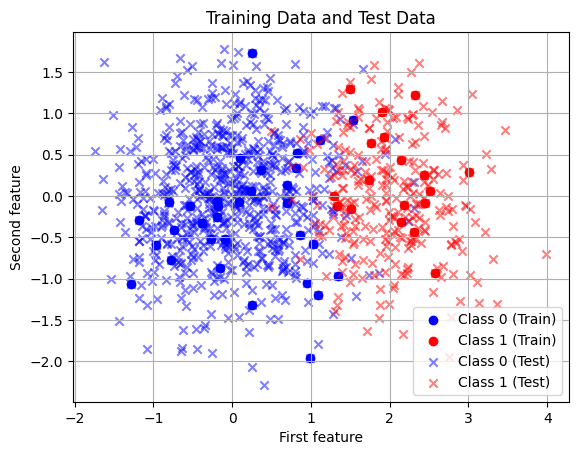

In [510]:

import numpy as np
import matplotlib.pyplot as plt

def generate_data(N, epsilon, p):
    # Define parameters
    mu0 = np.array([0, 0])
    mu1 = np.array([epsilon, 0])
    sigma0 = np.array([[0.5, 0], [0, 0.5]])
    sigma1 = np.array([[0.4, 0], [0, 0.4]])
    
    X = np.zeros((N, 2))
    y = np.zeros(N)
    
    seed = 15
    np.random.seed(seed)

    for i in range(N):
        # Step 1: Sample label y_i
        if np.random.rand() < p:
            y[i] = 1
            # Step 2: Sample x_i given y=1
            X[i] = np.random.multivariate_normal(mu1, sigma1)
        else:
            y[i] = 0
            # Step 2: Sample x_i given y=0
            X[i] = np.random.multivariate_normal(mu0, sigma0)
            
    return X, y

# Create our datasets
X_train, y_train = generate_data(50, 2, 0.3)
X_test, y_test = generate_data(1000, 2, 0.3)

# Visualize the training data
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1], color='blue', label='Class 0 (Train)', marker='o', alpha=1)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='red', label='Class 1 (Train)', marker='o', alpha=1)
plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='blue', label='Class 0 (Test)', marker='x', alpha=0.5)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='red', label='Class 1 (Test)', marker='x', alpha=0.5)
plt.title('Training Data and Test Data')
plt.xlabel('First feature')
plt.ylabel('Second feature')
plt.legend()
plt.grid()
plt.show()

**(b)** What is the mathematical expression for the optimal Bayes classifier in this setting? And for its boundary region? Remember that the Bayes classifier can be written in terms of the ratio of $\text{Prob}(Y = 1 \mid \mathbf{x})$ over $\text{Prob}(Y = 0 \mid \mathbf{x})$ and that the values of $\mathbf{x} \in \mathbb{R}^2$ for which this ratio is 1 are those defining its boundary. Beware, however, that in this exercise we're considering $\text{Prob}(Y = 1) = p$ and $\text{Prob}(Y = 0) = 1-p$, so they are not necessarily always equal.

Define the following ratio
$$r(x_0) = \frac{\text{Prob}(Y = 1 \mid \mathbf{x})}{\text{Prob}(Y = 0 \mid \mathbf{x})} = \frac{\frac{P(X|Y=1)P(Y=1)}{P(x_0)}}{\frac{P(X|Y=0)P(Y=0)}{P(x_0)}}$$
$$ = \frac{P(X|Y=1)P(Y=1)}{P(X|Y=0)P(Y=0)} =  \frac{P(X|Y=1)p}{P(X|Y=0)(1-p)} = \frac{3}{7} \frac{P(X|Y=1)}{P(X|Y=0)} $$
Thus when we have
$$r(x_0) = \frac{3}{7} \frac{P(X|Y=1)}{P(X|Y=0)}  > 1$$
the Bayes classifier must assign class $1$ to the point $x_0$. Hence we can write

$$f(x) = \mathbf{1}(r(x_0)>1) = 

\begin{array}{ll}
      1 & 3P(X|Y=1) \geq 7P(X|Y=0) \\
      0  & \text{otherwise} \\
\end{array} 
$$

And so the boundary region for our case is then 
$$ \mathcal{R} = \{ X \in \mathbb{R}^2 \: : \: 3 P(X|Y=1) = 7 P(X|Y=0) \} $$

and for a general p:
$$ \mathcal{R} = \{ X \in \mathbb{R}^2 \: : \: pP(X|Y=1) = (1-p)P(X|Y=0) \} $$

**(c)** Implement a Bayes classifier for this setup using scikit-learn's API as explained [here](https://scikit-learn.org/stable/developers/develop.html). This means that you will be writing a new classifier that follows the same logic and API as scikit-learn, but does not exist in the package. Use your implementation to estimate the error of the Bayes classifier on the samples from $\mathcal{D}(10^4 \mid 2, 0.3)$. How would you expect your results to change for other values of $\varepsilon$? Plot a curve showing how the Bayes error rate changes for different choices $\varepsilon$ (note that you will have to generate new datasets for this).

We would expect the Bayes error rate to decrease when epsilon increases. Epsilon is the expected value for the first feature x1 of the samples of x when y=1. The second feature x2 have the expected value 0 for both classes. So when epsilon is zero both classes have the same expected value and can only be distinguished by their slightly different variances which makes them very hard to separate and this would give the highest error rate. When epsilon increases the samples with x when y=1 will move to the right on the x1 axis and this would make it easier to tell the classes apart, so the error rate approaches 0.

In [511]:
from sklearn.base import ClassifierMixin
from scipy.stats import multivariate_normal

class BayesClassifier(ClassifierMixin):

    def __init__(self, epsilon=2, p=0.3):
        self.epsilon = epsilon
        self.p = p

    def fit(self, X, y): #Fit doesn't use X or y but have them to follow the same logic as scikit-learn
        #Parameters for P(X|Y=1) for this setup
        self.mu0 = np.array([0, 0])
        self.sigma0 = np.array([[0.5, 0], [0, 0.5]])
        #Parameters for P(X|Y=0) for this setup
        self.mu1 = np.array([self.epsilon, 0])
        self.sigma1 = np.array([[0.4, 0], [0, 0.4]])
        # Return the classifier
        return self

    def predict(self, X):
        #Calculate P(X|Y=1) with the pdf
        P_x_y0 = multivariate_normal.pdf(X, mean=self.mu0, cov=self.sigma0)
        #Calculate P(X|Y=0) with the pdf
        P_x_y1 = multivariate_normal.pdf(X, mean=self.mu1, cov=self.sigma1)
        #Return 1 or 0 as seen in the formula in (b)
        return (self.p * P_x_y1 >= (1-self.p) * P_x_y0).astype(int)

In [512]:
X, y = generate_data(10000, 2, 0.3)
bayes_model = BayesClassifier()
bayes_model.fit(X,y) #Fit doesn't use X or y but have it to follow the same logic as scikit-learn
error_rate = 1 - bayes_model.score(X, y)
print(f"Bayes error rate for D(10^4, 2, 0.3): {error_rate:.4f} ({error_rate*100:.2f}%)")

Bayes error rate for D(10^4, 2, 0.3): 0.0681 (6.81%)


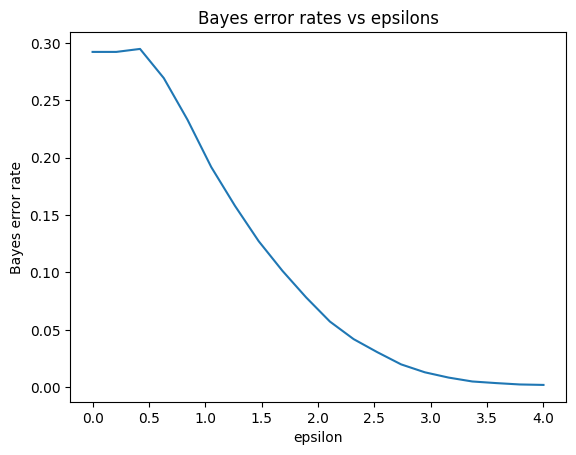

In [513]:
epsilons = np.linspace(0, 4, 20) 
error_rates = []

#Create datasets with different epsilon, classify them and calculate the Bayes error rate for them
for e in epsilons:
    X, y = generate_data(10000, e, 0.3)
    model = BayesClassifier(epsilon=e)
    model.fit(X,y)
    error_rates.append(1-model.score(X, y))

plt.plot(epsilons, error_rates)
plt.xlabel('epsilon')
plt.ylabel('Bayes error rate')
plt.title('Bayes error rates vs epsilons')
plt.show()

**(d)** Given the structure of the model generating the datasets, which classifier presented in our lectures seems to be the most adequate? Justify your answer in terms of the assumptions behind the construction of each classifier.

**(e)** Using `sklearn`, train a LDA, a QDA, and a logistic regression classifier on $\mathcal{D}_\text{train}$ and estimate their errors on the samples from $\mathcal{D}_\text{test}$. How do their errors compare to the value obtained in (c)? Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

In [514]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

bayes_model = BayesClassifier(epsilon=2, p=0.3)
bayes_model.fit(X_train, y_train) #Fit doesn't use X or y but have it to follow the same logic as scikit-learn
bayes_error = 1 - bayes_model.score(X_test, y_test)

print(f"Bayes error rate: {bayes_error:.4f} ({bayes_error*100:.2f}%)")

LDAmodel = LinearDiscriminantAnalysis()
LDAmodel.fit(X_train,y_train)
print(f"Test error rate for LDA: {1-LDAmodel.score(X_test, y_test):.4f} ({(1-LDAmodel.score(X_test, y_test))*100:.2f}%)")

QDAmodel = QuadraticDiscriminantAnalysis()
QDAmodel.fit(X_train,y_train)
print(f"Test error rate for QDA: {1-QDAmodel.score(X_test, y_test):.4f} ({(1-QDAmodel.score(X_test, y_test))*100:.2f}%)")

LRmodel = LogisticRegression()
LRmodel.fit(X_train,y_train)
print(f"Test error rate for Logistic Regression Classifier: {1-LRmodel.score(X_test, y_test):.4f} ({(1-LRmodel.score(X_test, y_test))*100:.2f}%)")

Bayes error rate: 0.0530 (5.30%)
Test error rate for LDA: 0.0600 (6.00%)
Test error rate for QDA: 0.0720 (7.20%)
Test error rate for Logistic Regression Classifier: 0.0670 (6.70%)


The test error for LDA and QDA was higher than the Bayes error rate in (c). Conversely the test error for the logistic regression classifier was lower than that found in (c).

Can we expect the gap between the Bayes error rate and test error for each classifier change when the number of samples in $\mathcal{D}_{\text{train}}$ in change? Justify your answer both theoretically and empirically.

Answer theoretically here

Empirically:

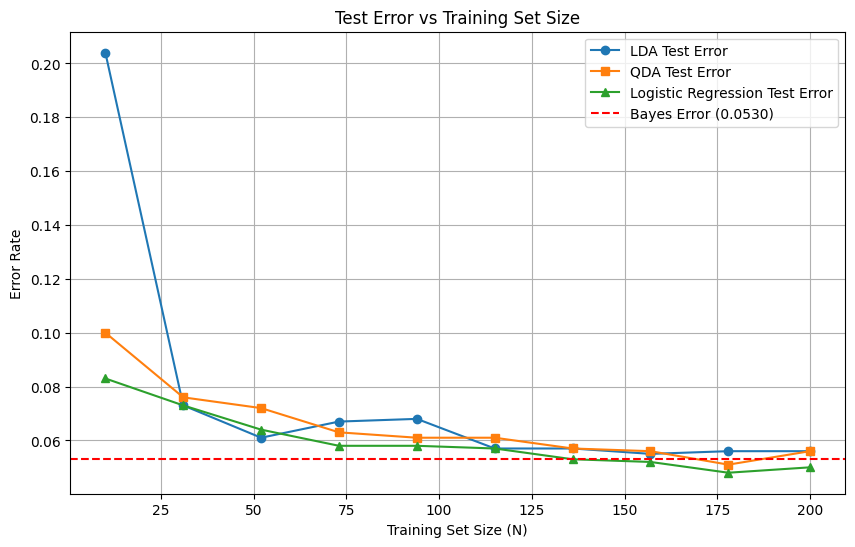

In [515]:
#Number of samples in Dtrain
N_values = np.linspace(10, 200, 10, dtype=int)
ldaerrors = []
qdaerrors = []
lrerrors = []

for N in N_values:
    X_train_N, y_train_N = generate_data(N, 2, 0.3)
    
    #Train LDA
    LDAmodel.fit(X_train_N, y_train_N)
    ldaerrors.append(1 - LDAmodel.score(X_test, y_test))
    
    #Train QDA
    QDAmodel.fit(X_train_N, y_train_N)
    qdaerrors.append(1 - QDAmodel.score(X_test, y_test))
    
    #Train Logistic Regression
    LRmodel.fit(X_train_N, y_train_N)
    lrerrors.append(1 - LRmodel.score(X_test, y_test))

#Plot
plt.figure(figsize=(10, 6))
plt.plot(N_values, ldaerrors, label='LDA Test Error', marker='o')
plt.plot(N_values, qdaerrors, label='QDA Test Error', marker='s')
plt.plot(N_values, lrerrors, label='Logistic Regression Test Error', marker='^')
#Bayes doesn't depend on the training data, so we can use the same value for all N
plt.axhline(y=bayes_error, color='r', linestyle='--', label=f'Bayes Error ({bayes_error:.4f})')
plt.xlabel('Training Set Size (N)')
plt.ylabel('Error Rate')
plt.title('Test Error vs Training Set Size')
plt.legend()
plt.grid(True)
plt.show()

**(f)** Consider a new test set defined as $\mathcal{D}'_\text{test} = \mathcal{D}(1000 \mid 0.5, 0.7)$. Use the same classifiers trained in (e) and estimate their new test errors. Do you observe any difference in the results? Can you explain what is happening?

In [516]:
# Generate the D'_test set
D_prime = generate_data(1000, 0.5, 0.7)

X_test_prime, y_test_prime= D_prime

print(f"Test error rate for Bayes (on D'): {1-bayes_model.score(X_test_prime, y_test_prime):.4f} ({(1-bayes_model.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for LDA (on D'): {1-LDAmodel.score(X_test_prime, y_test_prime):.4f} ({(1-LDAmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for QDA (on D'): {1-QDAmodel.score(X_test_prime, y_test_prime):.4f} ({(1-QDAmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")

print(f"Test error rate for Logistic Regression Classifier (on D'): {1-LRmodel.score(X_test_prime, y_test_prime):.4f} ({(1-LRmodel.score(X_test_prime, y_test_prime))*100:.2f}%)")


Test error rate for Bayes (on D'): 0.6070 (60.70%)
Test error rate for LDA (on D'): 0.5990 (59.90%)
Test error rate for QDA (on D'): 0.6090 (60.90%)
Test error rate for Logistic Regression Classifier (on D'): 0.6200 (62.00%)


Not sure if this was done right ... ? Like obviously if you change the test dataset to be very different from the train set on which the classsifier was trained then the error will be large ... 

## ▶️ Part 2: Real data

In this part we will consider the Titanic dataset available [here](https://www.kaggle.com/competitions/titanic/data). The goal here will be to build a machine learning model that predicts which passengers survived the Titanic shipwreck. Each passenger (i.e., data point) is composed of a set of categorical and continuous features, and its labels are either 0 (dead) or 1 (survived).

First of all, you should download both the `training` and the `test` datasets.

-- The `training` set should be used to build your machine learning models. The labels for each passenger are provided. Your model will be based on “features” like passengers’ gender and class. You can also use feature engineering to create new features.

-- The `test` set should be used to see how well your model performs on unseen data. For the test set, we do not provide the ground truth for each passenger. It is your job to predict these outcomes. For each passenger in the test set, use the model you trained to predict whether or not they survived the sinking of the Titanic.

Follow the guidelines from [here](https://www.kaggle.com/competitions/titanic/overview) to understand how to submit the results of your predictions on the `test` set and obtain the score of your model.

### Suggestions:

-- Don't hesitate to do some exploratory data analysis before building your machine learning model. You chould check, for instance, which kind of cross-validator seems the most appropriate for assessing the score of your classifier : are the data points completely IID? are they ordered somehow? split into groups? Beware of all this.

-- Since you will be handling predictors with different data types, it might be useful to take a look at the concept of `ColumnTransformer` from scikit-learn [here](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html). You could also check these two videos about how to build complext pipelines [1](https://www.youtube.com/watch?v=7TZ7j4HSzmE) and [2](https://www.youtube.com/watch?v=lhMqqauXtW0).

-- Take a look at the package [`skrub`](https://skrub-data.org/stable/). You would be surprised with how easy it is to get a very good score on this dataset using `tabular_learner`.

**(a)** Explain the feature engineering that you had to do with the dataset. If you've used `skrub`, explain how the encoding for each kind of predictor was decided.

**(b)** What type of classifier did you end up using? Why? What was your score in the public leaderboard from Kaggle?

### Summary of above
Explanatory data analysis:
- which kind of cross validator is appropriate?
- are data points completely Independently and Identically Distributed 
- Are they ordered ?
- split into groups ?


ColumnTransformer because multiple different data types ... 

- skrub --> tabular_learner 

### Data dictionary from Kaggle site

survival	Survival	0 = No, 1 = Yes

pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd

sex	Sex	

Age	Age in years	

sibsp	# of siblings / spouses aboard the Titanic	

parch	# of parents / children aboard the Titanic	

ticket	Ticket number	

fare	Passenger fare	

cabin	Cabin number	

embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

# Attempt with Decision Trees and some feature engineering 
[example of feature engineering](https://www.kaggle.com/code/yssefunc/best-feature-and-model-selection-for-titanic)


In [517]:
import pandas as pd
import numpy as np


X_train = pd.read_csv('train.csv')
X_test = pd.read_csv('test.csv')


In [518]:
X_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [519]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [520]:
X_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


We have missing age values. Also looking at X_train.csv we can see there are many missing values for Cabin. All other columns however have no missing values. 

In [521]:
#Data Cleaning and Data Drop Process
X_train['Fare'] = X_train['Fare'].fillna(X_train['Fare'].dropna().median())
X_train['Age'] = X_train['Age'].fillna(X_train['Age'].dropna().median())
# Change categorical data to numerical data
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})

# change the 2 null values to S then assign numerical values to the categoric column
X_train['Embarked']=X_train['Embarked'].fillna('S') 
X_train['Embarked'] = X_train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Drop the columns that we won't be using for classification
X_train = X_train.drop(columns=['Name', 'Ticket', 'Cabin'])

In [522]:
X_train.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


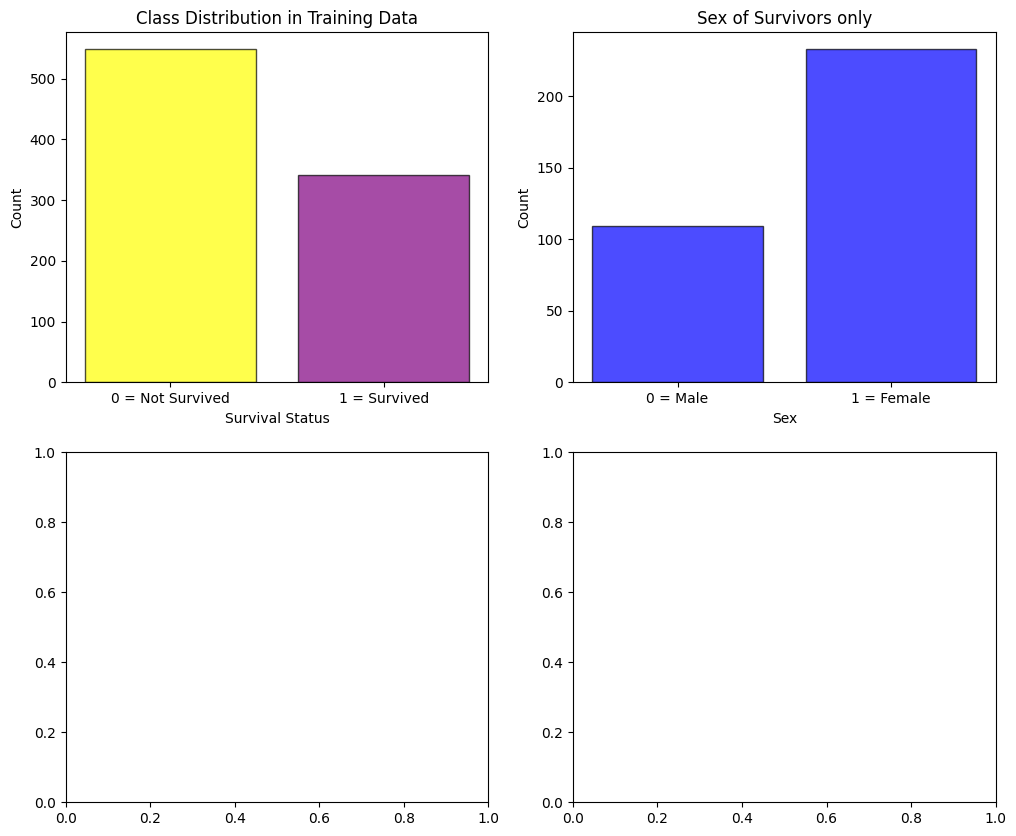

Number of samples in each class:
Survived
0    549
1    342
Name: count, dtype: int64
Proportion of each class:
Survived
0    0.616162
1    0.383838
Name: count, dtype: float64


In [523]:
# Check the class distribution
fig, ax = plt.subplots(2,2, figsize=(12, 10))
class_counts = X_train['Survived'].value_counts().sort_index()
sex_of_survivors = X_train.groupby('Survived')['Sex'].value_counts().unstack().fillna(0)

ax[0,0].bar([0, 1], class_counts, color=['yellow', 'purple'], edgecolor='black', alpha=0.7)
ax[0,0].set_xticks([0, 1])
ax[0,0].set_xticklabels(['0 = Not Survived', '1 = Survived'])
ax[0,0].set_xlabel('Survival Status')
ax[0,0].set_ylabel('Count')
ax[0,0].set_title('Class Distribution in Training Data')

ax[0,1].bar([0, 1], sex_of_survivors.loc[1], color='blue', edgecolor='black', alpha=0.7)
ax[0,1].set_xticks([0, 1])
ax[0,1].set_xticklabels(['0 = Male', '1 = Female'])
ax[0,1].set_xlabel('Sex')
ax[0,1].set_ylabel('Count')
ax[0,1].set_title('Sex of Survivors only')
plt.show()


print(f"Number of samples in each class:\n{class_counts}")
print(f"Proportion of each class:\n{class_counts / class_counts.sum()}")

Total number of men = 577

Total number of women = 314

In [524]:
X_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='str')

In [525]:
# Implementing Decision Tree classifier
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

random_state = 42


# Prepare the data for training
target = X_train['Survived']
features = X_train.drop(columns=['Survived'])
# Split the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=random_state)



In [526]:
# define the model 
for N in range(1, 11):
    dtree = tree.DecisionTreeClassifier(criterion = 'entropy', splitter = 'best', max_depth = None, min_samples_split = 2, min_samples_leaf = 1, max_features = None, random_state=N)
    dtree.fit(X_train, y_train)
    y_pred = dtree.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Decision Tree score with random_state={N}: {accuracy:.4f}")

# fit the model



Decision Tree score with random_state=1: 0.7761
Decision Tree score with random_state=2: 0.7799
Decision Tree score with random_state=3: 0.7799
Decision Tree score with random_state=4: 0.7799
Decision Tree score with random_state=5: 0.7761
Decision Tree score with random_state=6: 0.7985
Decision Tree score with random_state=7: 0.8022
Decision Tree score with random_state=8: 0.7873
Decision Tree score with random_state=9: 0.7948
Decision Tree score with random_state=10: 0.7910


In [527]:
# accuracy
print("Decision Tree score:", accuracy_score(y_test, y_pred))

Decision Tree score: 0.7910447761194029


Following code needs installation of tabicl and pytorch (I think but i used gemini to install it so idrk):

In [528]:
# Tabular Foundational Model: tabicl 
# from tabicl import TabICLClassifier

# clf = TabICLClassifier(random_state=random_state)
# clf.fit(X_train, y_train)


In [529]:
# y_pred_tabicl = clf.predict(X_test)
# print("TabICL Classifier score:", accuracy_score(y_test, y_pred_tabicl))